In [1]:
# CTR Model - Step 1: Import Libraries and Load Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)

import warnings
warnings.filterwarnings("ignore")


# Load feature-engineered dataset
df = pd.read_csv(
    "../data/processed/campaign_data_feature_engineered.csv"
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (10000, 45)


,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,...,CPC,conversion_rate,CPA,ROAS,profit,start_year,start_month,start_day,start_week,creative_to_campaign_age_ratio
0,CAMP_00001,Lead Generation,Facebook,Search,Mobile,Android,Text,728x90,Short,False,...,2.23,0.498,448.23,0.32,-606.79,2024,3,6,10,2.117647
1,CAMP_00002,Engagement,Facebook,Feed,Mobile,iOS,Image,320x50,Long,True,...,2.48,1.071,231.63,1.49,570.04,2024,1,26,4,2.818182
2,CAMP_00003,Conversions,Google Ads,Feed,Tablet,iOS,Video,1920x1080,Short,False,...,3.88,5.357,72.43,6.68,2468.70,2025,5,15,20,2.468750
3,CAMP_00004,Conversions,LinkedIn,Search,Desktop,iOS,Carousel,1920x1080,Short,False,...,8.29,2.439,339.89,0.49,-517.39,2024,7,21,29,1.781250
4,CAMP_00005,Brand Awareness,Facebook,Stories,Mobile,iOS,Image,1920x1080,Short,False,...,1.41,0.000,0.00,0.00,-425.82,2025,3,9,10,0.326923


In [2]:
# CTR Model - Step 2: Define Final Features

# Categorical features
categorical_features_ctr = [
    "campaign_objective",
    "platform",
    "device_type",
    "creative_format",
    "ad_copy_length",
    "income_bracket",
    "purchase_intent_score",
    "day_of_week",
    "industry_vertical"
]

# Numerical features
numerical_features_ctr = [
    "has_call_to_action",
    "retargeting_flag",
    "quarter",
    "campaign_day",
    "quality_score",
    "ad_spend"
]

# Combined feature list
model_features_ctr = (
    categorical_features_ctr +
    numerical_features_ctr
)

# Prepare features and target
X_ctr = df[model_features_ctr].copy()
y_ctr = df["CTR"].copy()

# Convert binary columns to integer
X_ctr["has_call_to_action"] = (
    X_ctr["has_call_to_action"].astype(int)
)

X_ctr["retargeting_flag"] = (
    X_ctr["retargeting_flag"].astype(int)
)

print("CTR Model Feature Setup")
print("-" * 40)
print("Total features:", len(model_features_ctr))
print("Categorical features:", len(categorical_features_ctr))
print("Numerical features:", len(numerical_features_ctr))
print("Samples:", len(X_ctr))

print("\nTarget: CTR")
print("Target mean:", round(y_ctr.mean(), 4))
print("Target standard deviation:", round(y_ctr.std(), 4))

print("\nFeatures:")
for feature in model_features_ctr:
    print("-", feature)

CTR Model Feature Setup
----------------------------------------
Total features: 15
Categorical features: 9
Numerical features: 6
Samples: 10000

Target: CTR
Target mean: 2.3143
Target standard deviation: 1.5733

Features:
- campaign_objective
- platform
- device_type
- creative_format
- ad_copy_length
- income_bracket
- purchase_intent_score
- day_of_week
- industry_vertical
- has_call_to_action
- retargeting_flag
- quarter
- campaign_day
- quality_score
- ad_spend


In [4]:
# CTR Model - Step 3: Create CTR Dataset and Remove Outliers

# Create a separate CTR dataset
df_ctr = df.copy()

# Convert binary features to integers
df_ctr["has_call_to_action"] = (
    df_ctr["has_call_to_action"].astype(int)
)

df_ctr["retargeting_flag"] = (
    df_ctr["retargeting_flag"].astype(int)
)

# Define CTR target
y_ctr = df_ctr["CTR"]

# Calculate IQR
Q1_ctr = y_ctr.quantile(0.25)
Q3_ctr = y_ctr.quantile(0.75)

IQR_ctr = Q3_ctr - Q1_ctr

lower_bound_ctr = Q1_ctr - 1.5 * IQR_ctr
upper_bound_ctr = Q3_ctr + 1.5 * IQR_ctr

# Identify outliers
outliers_ctr = (
    (y_ctr < lower_bound_ctr) |
    (y_ctr > upper_bound_ctr)
)

print("CTR Outlier Analysis")
print("-" * 40)
print("Q1:", round(Q1_ctr, 4))
print("Q3:", round(Q3_ctr, 4))
print("IQR:", round(IQR_ctr, 4))
print("Lower Bound:", round(lower_bound_ctr, 4))
print("Upper Bound:", round(upper_bound_ctr, 4))
print()
print("Number of outliers:", outliers_ctr.sum())
print(
    "Percentage of outliers:",
    round(outliers_ctr.mean() * 100, 2),
    "%"
)

# Remove outliers
df_ctr_clean = df_ctr.loc[~outliers_ctr].copy()

# Reset index
df_ctr_clean.reset_index(drop=True, inplace=True)

# Define cleaned features and target
X_ctr = df_ctr_clean[model_features_ctr].copy()
y_ctr = df_ctr_clean["CTR"].copy()

print()
print("Original samples:", len(df_ctr))
print("Samples after outlier removal:", len(df_ctr_clean))
print("Samples removed:", len(df_ctr) - len(df_ctr_clean))

print()
print("Cleaned dataset shape:", X_ctr.shape)
print("CTR mean after cleaning:", round(y_ctr.mean(), 4))
print("CTR standard deviation:", round(y_ctr.std(), 4))

CTR Outlier Analysis
----------------------------------------
Q1: 1.172
Q3: 3.0172
IQR: 1.8452
Lower Bound: -1.5959
Upper Bound: 5.7851

Number of outliers: 429
Percentage of outliers: 4.29 %

Original samples: 10000
Samples after outlier removal: 9571
Samples removed: 429

Cleaned dataset shape: (9571, 15)
CTR mean after cleaning: 2.0997
CTR standard deviation: 1.2176


In [5]:
# CTR Model - Step 4: Train-Test Split and Preprocessing

# Train-test split
X_train_ctr, X_test_ctr, y_train_ctr, y_test_ctr = train_test_split(
    X_ctr,
    y_ctr,
    test_size=0.20,
    random_state=42
)

# Create preprocessing pipeline
preprocessor_ctr = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_ctr
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features_ctr
        )
    ]
)

# Fit on training data
X_train_ctr_processed = preprocessor_ctr.fit_transform(
    X_train_ctr
)

# Transform test data
X_test_ctr_processed = preprocessor_ctr.transform(
    X_test_ctr
)

print("CTR Train-Test Split and Preprocessing")
print("-" * 45)
print("Training samples:", len(X_train_ctr))
print("Testing samples:", len(X_test_ctr))

print("\nProcessed training shape:",
      X_train_ctr_processed.shape)

print("Processed testing shape:",
      X_test_ctr_processed.shape)

print("\nTraining CTR mean:",
      round(y_train_ctr.mean(), 4))

print("Testing CTR mean:",
      round(y_test_ctr.mean(), 4))

CTR Train-Test Split and Preprocessing
---------------------------------------------
Training samples: 7656
Testing samples: 1915

Processed training shape: (7656, 49)
Processed testing shape: (1915, 49)

Training CTR mean: 2.0931
Testing CTR mean: 2.1259


In [6]:
# CTR Model - Step 5: Baseline Models

models_ctr = {
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradient Boosting": HistGradientBoostingRegressor(
        random_state=42
    )
}

results_ctr = []
trained_models_ctr = {}

for name, model in models_ctr.items():

    # Train model
    model.fit(
        X_train_ctr_processed,
        y_train_ctr
    )

    # Predict
    y_pred = model.predict(
        X_test_ctr_processed
    )

    # Evaluation metrics
    mae = mean_absolute_error(
        y_test_ctr,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_ctr,
            y_pred
        )
    )

    r2 = r2_score(
        y_test_ctr,
        y_pred
    )

    # Store results
    results_ctr.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

    trained_models_ctr[name] = model


# Create results table
results_ctr_df = pd.DataFrame(results_ctr)

# Sort by R²
results_ctr_df = results_ctr_df.sort_values(
    "R²",
    ascending=False
).reset_index(drop=True)

print("CTR Baseline Model Performance")
print("-" * 45)

results_ctr_df

CTR Baseline Model Performance
---------------------------------------------


,Model,MAE,RMSE,R²
0,HistGradient Boosting,0.545830,0.725529,0.647001
1,Gradient Boosting,0.598388,0.795703,0.575414
2,Random Forest,0.632531,0.834374,0.533141
3,Extra Trees,0.638348,0.861385,0.502425


In [7]:
# CTR Model - Step 6: Hyperparameter Tuning

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# HistGradientBoosting parameter distributions
param_distributions_ctr = {
    "max_iter": randint(100, 500),
    "learning_rate": uniform(0.01, 0.19),
    "max_leaf_nodes": randint(10, 50),
    "max_depth": randint(3, 12),
    "min_samples_leaf": randint(10, 60),
    "l2_regularization": uniform(0, 1)
}

# Base model
hgb_ctr = HistGradientBoostingRegressor(
    random_state=42
)

# Randomized search
random_search_ctr = RandomizedSearchCV(
    estimator=hgb_ctr,
    param_distributions=param_distributions_ctr,
    n_iter=40,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Run tuning
random_search_ctr.fit(
    X_train_ctr_processed,
    y_train_ctr
)

# Best model
best_ctr_model = random_search_ctr.best_estimator_

print("Best CTR Model Parameters:")
print(random_search_ctr.best_params_)

print("\nBest Cross-Validation R²:")
print(round(random_search_ctr.best_score_, 4))

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CTR Model Parameters:
{'l2_regularization': np.float64(0.5309345833171364), 'learning_rate': np.float64(0.0950788012688874), 'max_depth': 8, 'max_iter': 346, 'max_leaf_nodes': 13, 'min_samples_leaf': 20}

Best Cross-Validation R²:
0.6416


In [8]:
# CTR Model - Step 7: Evaluate Tuned Model

# Generate predictions
y_pred_ctr_tuned = best_ctr_model.predict(
    X_test_ctr_processed
)

# Calculate metrics
mae_ctr_tuned = mean_absolute_error(
    y_test_ctr,
    y_pred_ctr_tuned
)

rmse_ctr_tuned = np.sqrt(
    mean_squared_error(
        y_test_ctr,
        y_pred_ctr_tuned
    )
)

r2_ctr_tuned = r2_score(
    y_test_ctr,
    y_pred_ctr_tuned
)

# Display results
print("Tuned CTR Model Performance")
print("-" * 40)
print("MAE :", round(mae_ctr_tuned, 4))
print("RMSE:", round(rmse_ctr_tuned, 4))
print("R²  :", round(r2_ctr_tuned, 4))

Tuned CTR Model Performance
----------------------------------------
MAE : 0.5412
RMSE: 0.7224
R²  : 0.65


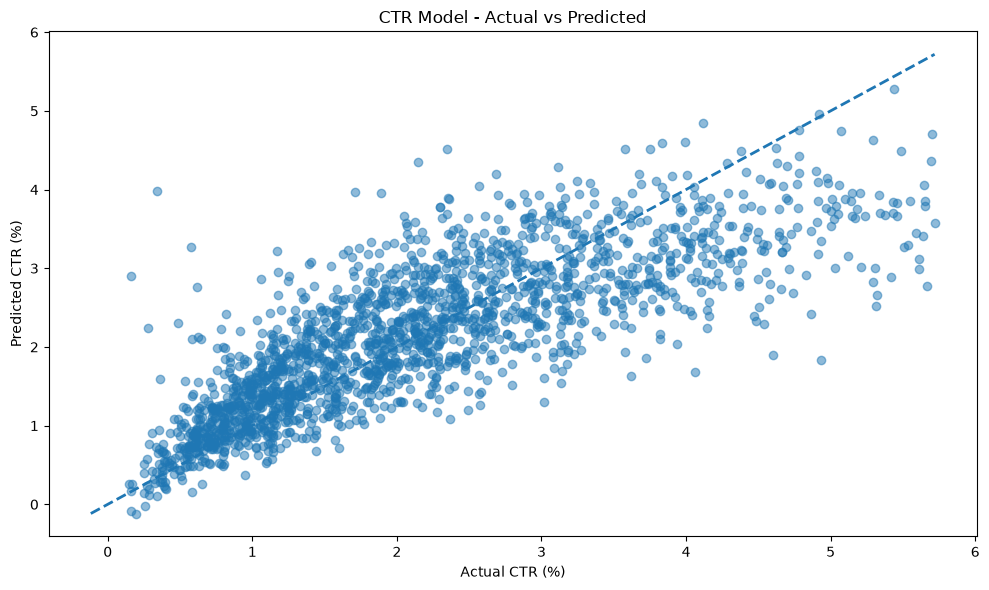

In [9]:
# CTR Model - Step 8: Actual vs Predicted CTR

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test_ctr,
    y_pred_ctr_tuned,
    alpha=0.5
)

# Perfect prediction reference line
min_value = min(
    y_test_ctr.min(),
    y_pred_ctr_tuned.min()
)

max_value = max(
    y_test_ctr.max(),
    y_pred_ctr_tuned.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual CTR (%)")
plt.ylabel("Predicted CTR (%)")
plt.title("CTR Model - Actual vs Predicted")

plt.tight_layout()
plt.show()

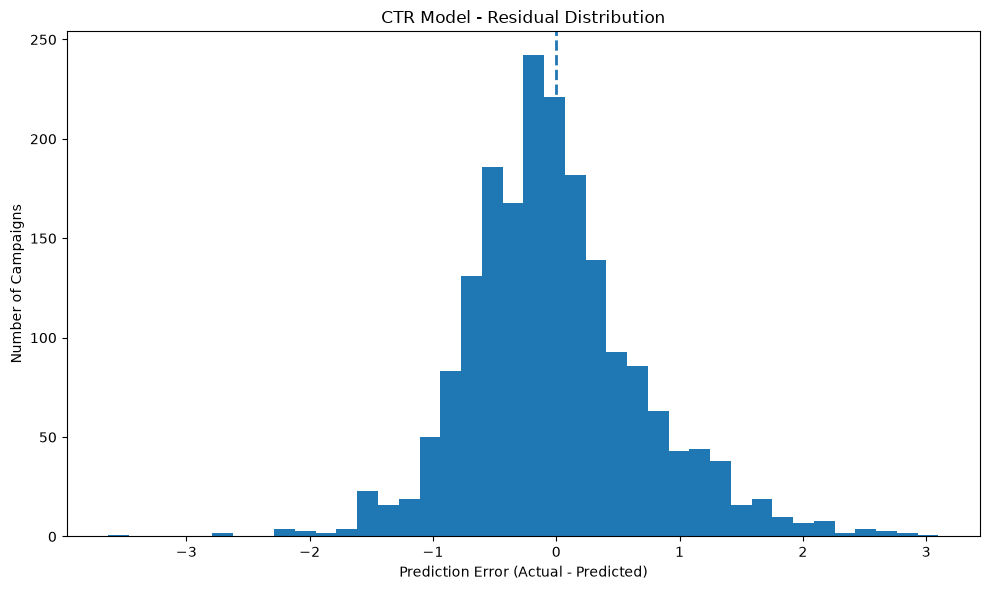

In [10]:
# CTR Model - Step 9: Residual Analysis

# Calculate residuals
residuals_ctr = (
    y_test_ctr.values - y_pred_ctr_tuned
)

# Plot residual distribution
plt.figure(figsize=(10, 6))

plt.hist(
    residuals_ctr,
    bins=40
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Number of Campaigns")
plt.title("CTR Model - Residual Distribution")

plt.tight_layout()
plt.show()

In [11]:
# CTR Model - Step 10: Feature Importance

from sklearn.inspection import permutation_importance

# Calculate permutation importance
perm_importance_ctr = permutation_importance(
    best_ctr_model,
    X_test_ctr_processed,
    y_test_ctr,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

# Get processed feature names
processed_feature_names_ctr = (
    preprocessor_ctr.get_feature_names_out()
)

# Create processed-level importance DataFrame
importance_ctr_df = pd.DataFrame({
    "Processed_Feature": processed_feature_names_ctr,
    "Importance": perm_importance_ctr.importances_mean
})

# Function to map encoded features back to original features
def get_original_feature_ctr(processed_feature):
    
    if processed_feature.startswith("numerical__"):
        return processed_feature.replace(
            "numerical__", ""
        )
    
    if processed_feature.startswith("categorical__"):
        feature_name = processed_feature.replace(
            "categorical__", ""
        )
        
        for feature in categorical_features_ctr:
            if feature_name.startswith(feature + "_"):
                return feature
    
    return processed_feature


# Map to original features
importance_ctr_df["Original_Feature"] = (
    importance_ctr_df["Processed_Feature"]
    .apply(get_original_feature_ctr)
)

# Aggregate one-hot encoded features
final_feature_importance_ctr = (
    importance_ctr_df
    .groupby("Original_Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Display final feature importance
final_feature_importance_ctr

,Original_Feature,Importance
0,quality_score,0.489877
1,creative_format,0.235170
2,day_of_week,0.230583
3,industry_vertical,0.219271
4,quarter,0.196498
5,ad_spend,0.091020
6,device_type,0.076945
7,platform,0.011525
8,has_call_to_action,0.004410
9,campaign_day,0.001782


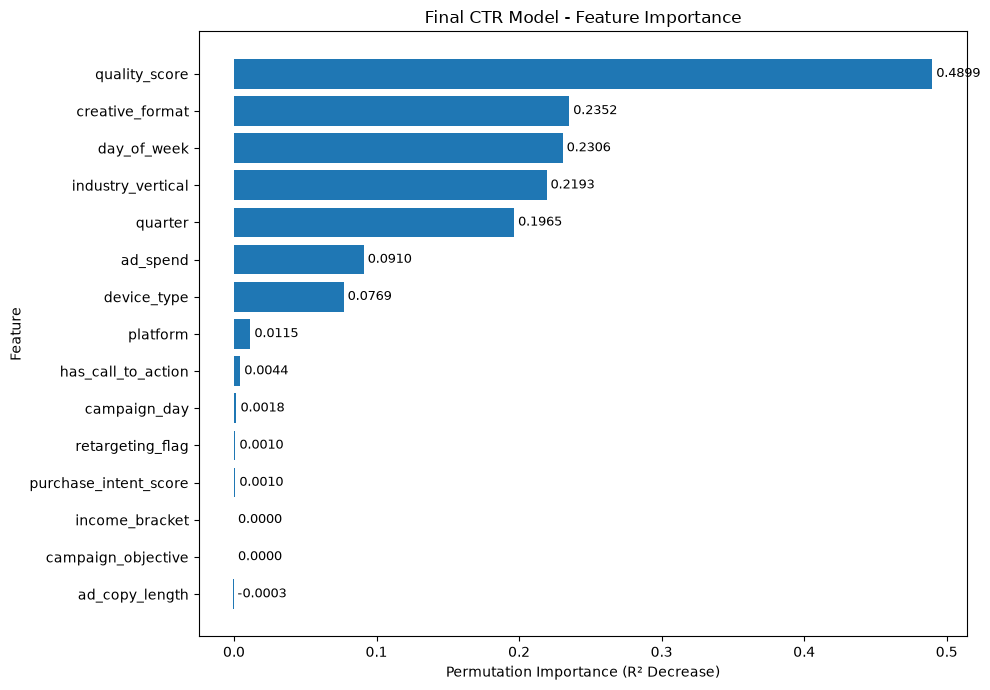

In [12]:
# CTR Model - Step 11: Feature Importance Visualization

plot_ctr_df = final_feature_importance_ctr.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    plot_ctr_df["Original_Feature"],
    plot_ctr_df["Importance"]
)

plt.xlabel("Permutation Importance (R² Decrease)")
plt.ylabel("Feature")
plt.title("Final CTR Model - Feature Importance")

# Add importance values
for bar, value in zip(
    bars,
    plot_ctr_df["Importance"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:.4f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [13]:
# CTR Model - Step 12: Save Final Model

import joblib
import json
import os

# Create models directory
os.makedirs("../models", exist_ok=True)

# Create complete pipeline
revenue_preprocessor = preprocessor_ctr

ctr_pipeline = Pipeline([
    ("preprocessor", revenue_preprocessor),
    ("model", best_ctr_model)
])

# Refit complete pipeline on training data
ctr_pipeline.fit(
    X_train_ctr,
    y_train_ctr
)

# Save complete pipeline
joblib.dump(
    ctr_pipeline,
    "../models/ctr_best_model.pkl"
)

# Save feature importance
final_feature_importance_ctr.to_csv(
    "../models/ctr_feature_importance.csv",
    index=False
)

# Model configuration
ctr_model_config = {
    "model_type": "HistGradientBoostingRegressor",
    "target": "CTR",

    "features": model_features_ctr,

    "categorical_features": categorical_features_ctr,
    "numerical_features": numerical_features_ctr,

    "outlier_method": "IQR",
    "lower_bound": float(lower_bound_ctr),
    "upper_bound": float(upper_bound_ctr),
    "outliers_removed": int(outliers_ctr.sum()),

    "metrics": {
        "MAE": float(mae_ctr_tuned),
        "RMSE": float(rmse_ctr_tuned),
        "R2": float(r2_ctr_tuned)
    },

    "best_parameters": {
        key: float(value) if isinstance(value, np.floating)
        else int(value) if isinstance(value, np.integer)
        else value
        for key, value in random_search_ctr.best_params_.items()
    }
}

# Save configuration
with open(
    "../models/ctr_model_config.json",
    "w"
) as file:
    json.dump(
        ctr_model_config,
        file,
        indent=4
    )

print("CTR model saved successfully.")
print()
print("Model:")
print("../models/ctr_best_model.pkl")
print()
print("Feature importance:")
print("../models/ctr_feature_importance.csv")
print()
print("Configuration:")
print("../models/ctr_model_config.json")

CTR model saved successfully.

Model:
../models/ctr_best_model.pkl

Feature importance:
../models/ctr_feature_importance.csv

Configuration:
../models/ctr_model_config.json


In [14]:
# CTR Model - Step 13: Verify Saved Model

# Load the saved CTR pipeline
loaded_ctr_model = joblib.load(
    "../models/ctr_best_model.pkl"
)

# Generate predictions using the saved pipeline
y_pred_ctr_loaded = loaded_ctr_model.predict(
    X_test_ctr
)

# Compare predictions
prediction_difference_ctr = np.abs(
    y_pred_ctr_tuned - y_pred_ctr_loaded
)

print("Saved CTR model loaded successfully.")
print()
print("Number of predictions:",
      len(y_pred_ctr_loaded))

print(
    "Maximum prediction difference:",
    prediction_difference_ctr.max()
)

print(
    "Average prediction difference:",
    prediction_difference_ctr.mean()
)

# Display sample predictions
verification_ctr_df = pd.DataFrame({
    "Actual CTR": y_test_ctr.values[:10],
    "Original Prediction": y_pred_ctr_tuned[:10],
    "Loaded Model Prediction": y_pred_ctr_loaded[:10]
})

verification_ctr_df

Saved CTR model loaded successfully.

Number of predictions: 1915
Maximum prediction difference: 0.0
Average prediction difference: 0.0


,Actual CTR,Original Prediction,Loaded Model Prediction
0,4.225,3.796770,3.796770
1,3.800,3.347459,3.347459
2,3.939,2.042344,2.042344
3,3.236,3.517397,3.517397
4,1.339,2.142478,2.142478
5,0.985,0.860149,0.860149
6,3.572,2.707078,2.707078
7,0.597,0.722151,0.722151
8,1.042,1.891587,1.891587
9,3.923,3.493821,3.493821


## CTR Modeling

The Click-Through Rate (CTR) model was developed to predict the percentage of impressions that result in clicks based on campaign characteristics and planned ad spend.

### Data Preparation

- The CTR target was analyzed for extreme values using the **IQR method**.
- **429 outliers (4.29%)** were removed.
- The resulting dataset contained **9,571 campaigns**.
- The data was divided into **80% training and 20% testing** sets.
- Categorical variables were encoded using **One-Hot Encoding**, while numerical variables were standardized using **StandardScaler**.

### Features Used

The same 15 finalized features were used to maintain a consistent input structure across the prediction models:

- Campaign Objective
- Platform
- Device Type
- Creative Format
- Ad Copy Length
- Income Bracket
- Purchase Intent Score
- Day of Week
- Industry Vertical
- Has Call to Action
- Retargeting Flag
- Quarter
- Campaign Day
- Quality Score
- Ad Spend

### Model Selection

Several regression algorithms were evaluated. **HistGradientBoosting Regressor** achieved the best baseline performance and was selected for hyperparameter tuning.

Randomized Search with 5-fold cross-validation was used to optimize the model.

### Final Model Performance

The tuned HistGradientBoosting model achieved:

- **MAE:** 0.5412
- **RMSE:** 0.7224
- **R² Score:** 0.6500

The model explains approximately **65% of the variation in CTR** on the test dataset.

### Key Findings

- **Quality Score** was the most influential feature for CTR prediction.
- **Creative Format**, **Day of Week**, **Industry Vertical**, and **Quarter** were also important predictors.
- **Ad Spend** had a moderate contribution.
- The actual-vs-predicted analysis showed a clear positive relationship between predicted and actual CTR.
- Residual analysis indicated that prediction errors were generally concentrated around zero, although the model had greater difficulty with some higher-CTR campaigns.

The final CTR model, preprocessing pipeline, feature importance data, and model configuration were saved for later use in the recommendation engine and dashboard.